In [26]:
import matplotlib.pyplot as plt
import torch
from torch import nn

from laya.scoring import log_score

In [27]:
torch.manual_seed(42)

true_distribution = torch.tensor(
    [
        0.7,
        0.2,
        0.1,
    ]
)

outcome = torch.multinomial(
    true_distribution,
    num_samples=1,
    replacement=True,
)

outcome

tensor([0])

RL


In [28]:
# policy
class ProbabilityPolicy(nn.Module):
    def __init__(
        self,
        n_options: int,
    ) -> None:
        super().__init__()

        self.logits = nn.Parameter(torch.zeros(n_options))

    def forward(self) -> torch.Tensor:
        return torch.softmax(
            self.logits,
            dim=-1,
        )

In [29]:
policy = ProbabilityPolicy(n_options=3)

policy()

tensor([0.3333, 0.3333, 0.3333], grad_fn=<SoftmaxBackward0>)

In [30]:
# action
n_candidates = 8
exploration_std = 0.5

base_logits = policy.logits

noise = torch.randn(n_candidates, 3) * exploration_std

candidate_logits = base_logits.detach() + noise

candidate_probabilities = torch.softmax(candidate_logits, dim=-1)

candidate_probabilities, candidate_probabilities.shape

(tensor([[0.2528, 0.1158, 0.6314],
         [0.3424, 0.3851, 0.2725],
         [0.5065, 0.3134, 0.1800],
         [0.4389, 0.2448, 0.3164],
         [0.2020, 0.5331, 0.2649],
         [0.3052, 0.2494, 0.4453],
         [0.1670, 0.5986, 0.2344],
         [0.1780, 0.1271, 0.6949]]),
 torch.Size([8, 3]))

In [31]:
outcome = torch.multinomial(true_distribution, num_samples=1, replacement=True)

outcome

tensor([1])

In [32]:
# reward
candidate_outcomes = outcome.expand(n_candidates)

rewards = log_score(candidate_probabilities, candidate_outcomes)

rewards

tensor([-2.1560, -0.9543, -1.1602, -1.4075, -0.6291, -1.3886, -0.5131, -2.0625])

eval


In [33]:
baseline = rewards.mean()

baseline

tensor(-1.2839)

In [34]:
advantages = rewards - baseline

advantages

tensor([-0.8721,  0.3296,  0.1237, -0.1236,  0.6548, -0.1047,  0.7708, -0.7786])

In [35]:
distribution = torch.distributions.Normal(
    loc=policy.logits,
    scale=exploration_std,
)
log_probabilities = distribution.log_prob(candidate_logits).sum(dim=-1)

log_probabilities

tensor([-3.5639, -1.2575, -4.1221, -2.0391, -2.2278, -1.1655, -2.7730, -3.9229],
       grad_fn=<SumBackward1>)

In [36]:
policy_loss = -(advantages.detach() * log_probabilities).mean()

policy_loss

tensor(-0.2519, grad_fn=<NegBackward0>)

optimize


In [37]:
optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=0.05,
)
optimizer.zero_grad()

policy_loss.backward()

optimizer.step()
policy.logits, policy()

(Parameter containing:
 tensor([-0.0500,  0.0500, -0.0500], requires_grad=True),
 tensor([0.3220, 0.3559, 0.3220], grad_fn=<SoftmaxBackward0>))

using rlcd step


In [38]:
from laya.rlcd import rlcd_step

In [39]:
torch.manual_seed(42)

policy = ProbabilityPolicy(
    n_options=3,
)

optimizer = torch.optim.Adam(
    policy.parameters(),
    lr=0.03,
)

# training
n_steps = 5000

history = []
reward_history = []

for step in range(n_steps):
    outcome = torch.multinomial(
        true_distribution,
        num_samples=1,
        replacement=True,
    )

    loss, reward = rlcd_step(
        policy=policy,
        optimizer=optimizer,
        outcome=outcome,
        n_candidates=32,
        exploration_std=0.4,
    )

    history.append(policy().detach().clone())

    reward_history.append(reward)

policy()

tensor([0.7236, 0.1811, 0.0953], grad_fn=<SoftmaxBackward0>)

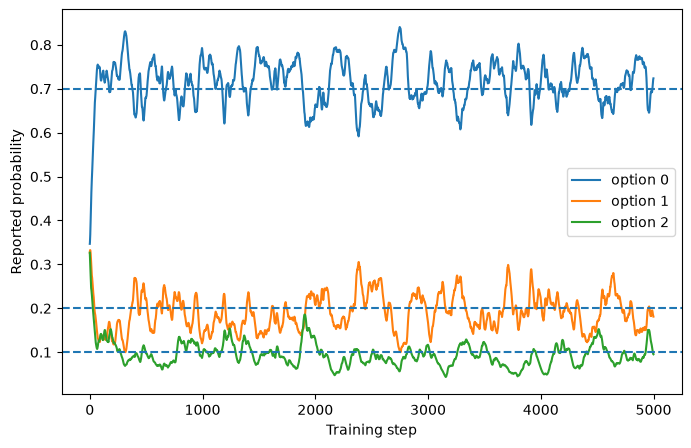

In [ ]:
history_tensor = torch.stack(history)

plt.figure(figsize=(8, 5))

for option_index in range(3):
    plt.plot(
        history_tensor[:, option_index],
        label=f"option {option_index}",
    )

plt.axhline(
    0.7,
    linestyle="--",
)

plt.axhline(
    0.2,
    linestyle="--",
)

plt.axhline(
    0.1,
    linestyle="--",
)

plt.xlabel("Training step")
plt.ylabel("Reported probability")
plt.legend()
plt.show()

baseline helper


In [ ]:
def reinforce_without_baseline(
    policy,
    optimizer,
    outcome,
    n_candidates=32,
    exploration_std=0.4,
):
    base_logits = policy.logits

    candidate_logits = (
        base_logits.detach()
        + torch.randn(
            n_candidates,
            base_logits.shape[-1],
        )
        * exploration_std
    )

    candidate_probabilities = torch.softmax(
        candidate_logits,
        dim=-1,
    )

    rewards = log_score(
        candidate_probabilities,
        outcome.expand(n_candidates),
    )

    distribution = torch.distributions.Normal(
        base_logits,
        exploration_std,
    )

    log_probs = distribution.log_prob(candidate_logits).sum(dim=-1)

    loss = -(rewards.detach() * log_probs).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()